# PROBLEM STATEMENT:
In this project report we are aimed to analyze the given dataset and first to scraped the data and then find the answers to few questions i.e.   
1) Which area is most expensive?
2) What are the features that leads to higher price of the airbnb.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('airbnb_listings.csv')
df

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2.793400e+04,https://www.airbnb.com/rooms/27934,2.025030e+13,3/21/2025,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,https://a0.muscache.com/pictures/566374/23157b...,120437,...,4.91,4.66,4.75,NaN,f,1,1,0,0,0.41
1,2.797900e+04,https://www.airbnb.com/rooms/27979,2.025030e+13,3/20/2025,previous scrape,"Easy going landlord,easy place",NaN,NaN,https://a0.muscache.com/pictures/106247594/1d6...,120541,...,NaN,NaN,NaN,NaN,f,2,1,1,0,NaN
2,2.874500e+04,https://www.airbnb.com/rooms/28745,2.025030e+13,3/20/2025,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,https://a0.muscache.com/pictures/160369/92a7ec...,123784,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
3,4.751600e+04,https://www.airbnb.com/rooms/47516,2.025030e+13,3/20/2025,city scrape,Beautiful waterfront house,NaN,NaN,https://a0.muscache.com/pictures/271998/b090ad...,214456,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
4,4.873600e+04,https://www.airbnb.com/rooms/48736,2.025030e+13,3/20/2025,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,NaN,https://a0.muscache.com/pictures/12465296/e9c0...,222005,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27543,1.379670e+18,https://www.airbnb.com/rooms/1379672358263667520,2.025030e+13,3/20/2025,city scrape,"King Bed Room, 500m the Pink Line MRT,Near Air...",King bed room<br />2 shared bathrooms<br />Air...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,679097032,...,NaN,NaN,NaN,NaN,f,3,1,2,0,NaN
27544,1.379720e+18,https://www.airbnb.com/rooms/1379715999009665895,2.025030e+13,3/20/2025,city scrape,2.曼谷特惠公寓出租/月租特惠/一室一厅/MRT Bangson站3分钟,"The project is located in Bangsue district, ju...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,653148266,...,NaN,NaN,NaN,NaN,f,140,140,0,0,NaN
27545,1.379720e+18,https://www.airbnb.com/rooms/1379720665926456231,2.025030e+13,3/20/2025,city scrape,2.曼谷特惠公寓出租/月租特惠/一室一厅/MRT Bangson站3分钟,"The project is located in Bangsue district, ju...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,653148266,...,NaN,NaN,NaN,NaN,f,140,140,0,0,NaN
27546,1.379720e+18,https://www.airbnb.com/rooms/1379724086373712054,2.025030e+13,3/20/2025,city scrape,2.曼谷特惠公寓出租/月租特惠/一室一厅/MRT Bangson站3分钟,"The project is located in Bangsue district, ju...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,653148266,...,NaN,NaN,NaN,NaN,f,140,140,0,0,NaN


In [3]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

### Removing irrelevant columns

In [5]:
df.drop(columns=["id", "listing_url", "scrape_id", "last_scraped", "source", "name", "description", "neighborhood_overview", "picture_url", "host_id", "host_url", "host_name", "host_since", "host_about", "host_response_rate", "host_acceptance_rate", "host_thumbnail_url", "host_picture_url",  "host_listings_count", "host_verifications", "host_has_profile_pic","neighbourhood", "neighbourhood_group_cleansed", "latitude", "longitude", "room_type", "bathrooms", "bathrooms_text",  "beds","minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights", "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm", "calendar_updated", "has_availability", "availability_30", "availability_60", "availability_90", "availability_365", "calendar_last_scraped", "number_of_reviews_ltm", "number_of_reviews_l30d", "availability_eoy", "number_of_reviews_ly", "estimated_occupancy_l365d", "estimated_revenue_l365d", "first_review", "last_review",  "license", "instant_bookable", "calculated_host_listings_count", "calculated_host_listings_count_entire_homes", "calculated_host_listings_count_private_rooms", "calculated_host_listings_count_shared_rooms"],inplace=True)
df

,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,accommodates,bedrooms,...,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,"Bangkok, Thailand",NaN,t,Victory Monument,2.0,t,Ratchathewi,Entire condo,2,1.0,...,1665.0,65,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.41
1,"Bangkok, Thailand",NaN,f,NaN,4.0,f,Bang Na,Private room in rental unit,2,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Bangkok, Thailand",NaN,f,Bang Kapi,1.0,f,Bang Kapi,Private room in rental unit,2,1.0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"New Delhi, India",NaN,f,NaN,2.0,t,Don Mueang,Entire home,1,4.0,...,4373.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Bangkok, Thailand",within an hour,f,NaN,1.0,t,Rat Burana,Private room in rental unit,2,1.0,...,1930.0,1,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27543,"Bangkok, Thailand",within a few hours,f,NaN,5.0,t,Min Buri,Private room in home,2,1.0,...,440.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27544,"Bangkok, Thailand",within an hour,f,NaN,144.0,t,Bang Sue,Entire rental unit,2,1.0,...,760.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27545,"Bangkok, Thailand",within an hour,f,NaN,144.0,t,Bang Sue,Entire rental unit,2,1.0,...,760.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27546,"Bangkok, Thailand",within an hour,f,NaN,144.0,t,Bang Sue,Entire rental unit,2,1.0,...,760.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum()

host_location                   6624
host_response_time              4066
host_is_superhost               1319
host_neighbourhood             18115
host_total_listings_count          2
host_identity_verified             2
neighbourhood_cleansed             0
property_type                      0
accommodates                       0
bedrooms                        1281
amenities                          0
price                           5390
number_of_reviews                  0
review_scores_rating            9466
review_scores_accuracy          9466
review_scores_cleanliness       9467
review_scores_checkin           9470
review_scores_communication     9467
review_scores_location          9471
review_scores_value             9472
reviews_per_month               9466
dtype: int64

In [7]:
pd.isnull(df)

,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,accommodates,bedrooms,...,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,True,False,False,False,False,False,True,...,True,False,True,True,True,True,True,True,True,True
2,False,True,False,False,False,False,False,False,False,False,...,True,False,True,True,True,True,True,True,True,True
3,False,True,False,True,False,False,False,False,False,False,...,False,False,True,True,True,True,True,True,True,True
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27543,False,False,False,True,False,False,False,False,False,False,...,False,False,True,True,True,True,True,True,True,True
27544,False,False,False,True,False,False,False,False,False,False,...,False,False,True,True,True,True,True,True,True,True
27545,False,False,False,True,False,False,False,False,False,False,...,False,False,True,True,True,True,True,True,True,True
27546,False,False,False,True,False,False,False,False,False,False,...,False,False,True,True,True,True,True,True,True,True


### Now handling the missing and NaN values

In [9]:
df['host_location'].fillna('unknown',inplace=True)
df['host_response_time'].fillna("N/A",inplace=True)
df['host_is_superhost'].fillna("",inplace=True)
df['host_neighbourhood'].fillna("other",inplace=True)
df['host_total_listings_count'].fillna(0,inplace=True)
df['host_identity_verified'].fillna('f',inplace=True)
df['bedrooms'].fillna(1,inplace=True)
df.dropna(subset=['price'],inplace=True)
df['review_scores_rating'].fillna(0,inplace=True)
df['review_scores_accuracy'].fillna('N/A',inplace=True)
df['review_scores_cleanliness'].fillna('N/A',inplace=True)
df['review_scores_checkin'].fillna('N/A',inplace=True)
df['review_scores_communication'].fillna('N/A',inplace=True)
df['review_scores_location'].fillna('N/A',inplace=True)
df['review_scores_value'].fillna('N/A',inplace=True)
df['reviews_per_month'].fillna('N/A',inplace=True)

C:\Users\KARTIK\AppData\Local\Temp\ipykernel_31344\1434002341.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_location'].fillna('unknown',inplace=True)
C:\Users\KARTIK\AppData\Local\Temp\ipykernel_31344\1434002341.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [10]:
pd.isnull(df)

,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,accommodates,bedrooms,...,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27543,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
27544,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
27545,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
27546,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Now, we can see our data is cleaned now and contain no null or NaN values.

### Checking for valid datatype

In [13]:
df.dtypes

host_location                   object
host_response_time              object
host_is_superhost               object
host_neighbourhood              object
host_total_listings_count      float64
host_identity_verified          object
neighbourhood_cleansed          object
property_type                   object
accommodates                     int64
bedrooms                       float64
amenities                       object
price                          float64
number_of_reviews                int64
review_scores_rating           float64
review_scores_accuracy          object
review_scores_cleanliness       object
review_scores_checkin           object
review_scores_communication     object
review_scores_location          object
review_scores_value             object
reviews_per_month               object
dtype: object

Here, the price column is of dtype 'object' so we have to change it to integer.

In [15]:
df['price']=df['price'].astype('float')

## FEATURE ENGINEERING

In [17]:
df['amenities_count'] = df['amenities'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

## EDA[Exploratory Data Analysis]

In [19]:
df.head()

,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,accommodates,bedrooms,...,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,amenities_count
0,"Bangkok, Thailand",N/A,t,Victory Monument,2.0,t,Ratchathewi,Entire condo,2,1.0,...,65,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.41,25
3,"New Delhi, India",N/A,f,other,2.0,t,Don Mueang,Entire home,1,4.0,...,0,0.00,N/A,N/A,N/A,N/A,N/A,N/A,N/A,9
4,"Bangkok, Thailand",within an hour,f,other,1.0,t,Rat Burana,Private room in rental unit,2,1.0,...,1,5.00,5.0,5.0,5.0,5.0,5.0,5.0,0.01,30
5,"Bangkok, Thailand",within a few hours,t,Silom,9.0,t,Bang Rak,Private room in serviced apartment,2,1.0,...,38,4.81,4.73,4.84,4.84,4.89,4.78,4.81,0.22,21
6,"Bangkok, Thailand",within a few hours,t,Silom,9.0,t,Sathon,Room in hostel,2,1.0,...,210,4.80,4.77,4.85,4.87,4.85,4.74,4.69,1.22,17


In [20]:
df.tail()

,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,accommodates,bedrooms,...,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,amenities_count
27543,"Bangkok, Thailand",within a few hours,f,other,5.0,t,Min Buri,Private room in home,2,1.0,...,0,0.0,N/A,N/A,N/A,N/A,N/A,N/A,N/A,20
27544,"Bangkok, Thailand",within an hour,f,other,144.0,t,Bang Sue,Entire rental unit,2,1.0,...,0,0.0,N/A,N/A,N/A,N/A,N/A,N/A,N/A,11
27545,"Bangkok, Thailand",within an hour,f,other,144.0,t,Bang Sue,Entire rental unit,2,1.0,...,0,0.0,N/A,N/A,N/A,N/A,N/A,N/A,N/A,11
27546,"Bangkok, Thailand",within an hour,f,other,144.0,t,Bang Sue,Entire rental unit,2,1.0,...,0,0.0,N/A,N/A,N/A,N/A,N/A,N/A,N/A,11
27547,"Bangkok, Thailand",within an hour,f,other,144.0,t,Bang Sue,Entire rental unit,2,1.0,...,0,0.0,N/A,N/A,N/A,N/A,N/A,N/A,N/A,10


In [21]:
df.shape

(22158, 22)

In [22]:
df.describe(include='all')

,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,accommodates,bedrooms,...,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,amenities_count
count,22158,22158,22158,22158,22158.000000,22158,22158,22158,22158.000000,22158.000000,...,22158.000000,22158.000000,22158,22158,22158,22158,22158,22158,22158,22158.000000
unique,356,5,3,122,NaN,2,50,73,NaN,NaN,...,NaN,NaN,134,144,132,125,151,140,689,NaN
top,"Bangkok, Thailand",within an hour,f,other,NaN,t,Vadhana,Entire rental unit,NaN,NaN,...,NaN,NaN,N/A,N/A,N/A,N/A,N/A,N/A,N/A,NaN
freq,14549,17019,13438,15247,NaN,21829,3763,9844,NaN,NaN,...,NaN,NaN,6678,6678,6681,6679,6681,6681,6678,NaN
mean,NaN,NaN,NaN,NaN,53.682868,NaN,NaN,NaN,3.174880,1.380991,...,22.381713,3.289759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.360592
std,NaN,NaN,NaN,NaN,140.937809,NaN,NaN,NaN,2.282042,1.177171,...,56.006014,2.202000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.903221
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,1.000000,0.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,2.000000,1.000000,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000
50%,NaN,NaN,NaN,NaN,14.000000,NaN,NaN,NaN,2.000000,1.000000,...,3.000000,4.680000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000
75%,NaN,NaN,NaN,NaN,54.000000,NaN,NaN,NaN,4.000000,1.000000,...,20.000000,4.940000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.000000


In [23]:
df.describe(include='object')

,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_identity_verified,neighbourhood_cleansed,property_type,amenities,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
count,22158,22158,22158,22158,22158,22158,22158,22158,22158,22158,22158,22158,22158,22158,22158
unique,356,5,3,122,2,50,73,17658,134,144,132,125,151,140,689
top,"Bangkok, Thailand",within an hour,f,other,t,Vadhana,Entire rental unit,"[""TV"", ""Wifi"", ""Fire extinguisher"", ""Outdoor s...",N/A,N/A,N/A,N/A,N/A,N/A,N/A
freq,14549,17019,13438,15247,21829,3763,9844,172,6678,6678,6681,6679,6681,6681,6678


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22158 entries, 0 to 27547
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_location                22158 non-null  object 
 1   host_response_time           22158 non-null  object 
 2   host_is_superhost            22158 non-null  object 
 3   host_neighbourhood           22158 non-null  object 
 4   host_total_listings_count    22158 non-null  float64
 5   host_identity_verified       22158 non-null  object 
 6   neighbourhood_cleansed       22158 non-null  object 
 7   property_type                22158 non-null  object 
 8   accommodates                 22158 non-null  int64  
 9   bedrooms                     22158 non-null  float64
 10  amenities                    22158 non-null  object 
 11  price                        22158 non-null  float64
 12  number_of_reviews            22158 non-null  int64  
 13  review_scores_rating 

In [56]:
df.groupby('host_location')['price'].sum().sort_values(ascending=False)

host_location
Bangkok, Thailand           38796913.0
unknown                     12942134.0
Thailand                     1292233.0
England, United Kingdom       465889.0
Singapore                     401487.0
                               ...    
Reggio Calabria, Italy           600.0
Columbus, OH                     560.0
Bang Khae, Thailand              500.0
Wang Thonglang, Thailand         411.0
Bang Chan, Thailand              370.0
Name: price, Length: 356, dtype: float64

The most expensive aibnb is in 'Bankok Thailand'.

In [25]:
df.groupby('host_location')['price'].mean().sort_values(ascending=False)

host_location
Caloocan, Philippines       134552.000000
Copenhagen, Denmark         101143.000000
Sandton, South Africa        33638.000000
Ellicott City, MD            33638.000000
Montréal, Canada             31905.500000
                                ...      
Bang Khae, Thailand            500.000000
Wang Thonglang, Thailand       411.000000
Bang Chan, Thailand            370.000000
Thep Krasatti, Thailand        336.500000
Bangkok Noi, Thailand          143.833333
Name: price, Length: 356, dtype: float64

We can see clearly that 'Caloocan philippines' is the most expensive area.

### Now finding features correlated to Price, as we have to find the features leading higher prices

<Axes: >

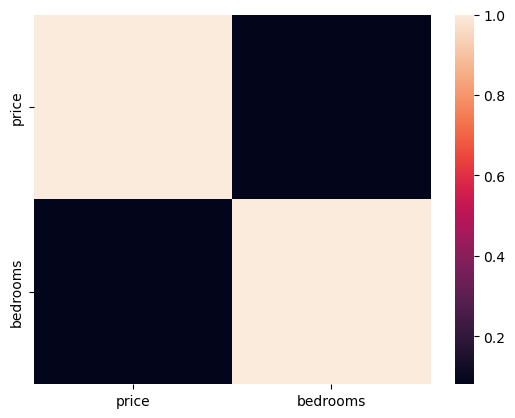

In [28]:
sns.heatmap(df[['price','bedrooms']].corr())

They both are not correlated to each other at all.

<Axes: >

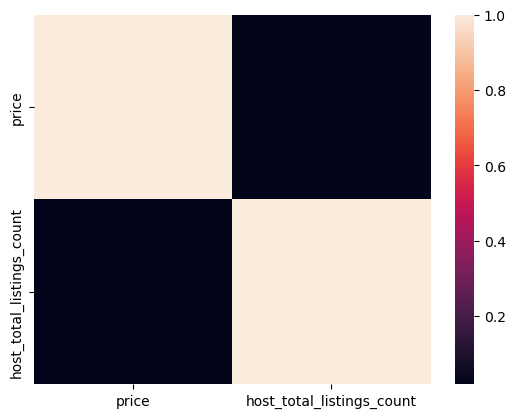

In [30]:
sns.heatmap(df[['price','host_total_listings_count']].corr())

These two too are not correlated to each other.

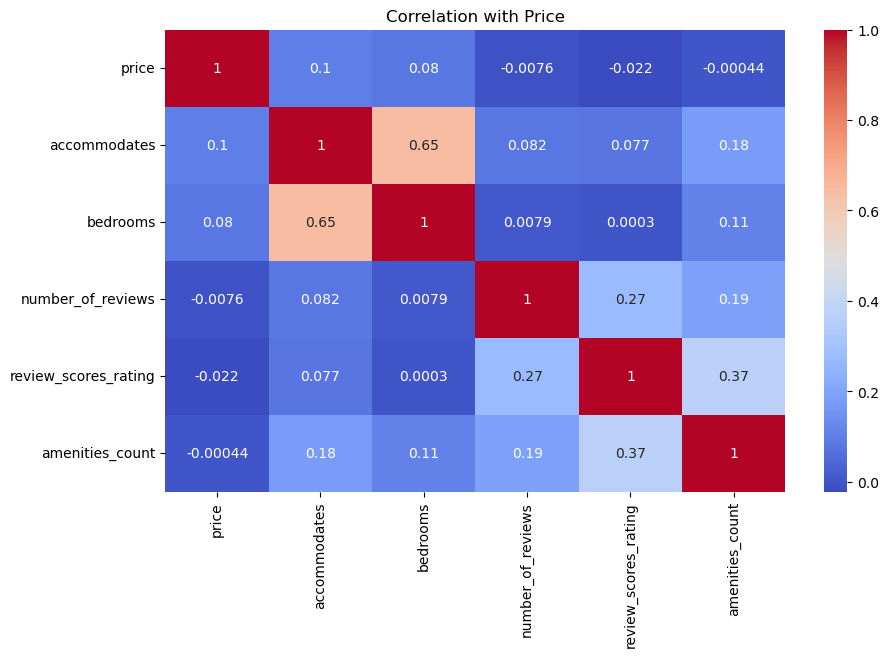

In [62]:
numeric_features = ['price', 'accommodates', 'bedrooms', 'number_of_reviews', 'review_scores_rating',
                    'amenities_count']

corr = df[numeric_features].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation with Price")
plt.savefig('airbnb1',bbox_inches='tight')
plt.show()


 From the above heatmap we can conclude that the price is influenced by 'accommodates', 'bedrooms', 'number of amaneties', 'review score rating.

## FINAL ANALYSIS:

1) The most expensive airbnb is in "Bankok, Thailand".
2) The most expensive area is "Calcoon philippines".
3) Features lead to higher prices are:
   1. Accomodates
   2. Number of bedrooms
   3. number of amaneties
   4. review score rating